In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [15]:
ISIC_DF = pd.read_csv("/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_GroundTruth.csv")
ISIC_DF.head()

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/tmp/ipykernel_55/1535550507.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stat_ISIC.index, y=stat_ISIC.values, ax=ax1, palette=colors)
/tmp/ipykernel_55/1535550507.py:15: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(x=stat_ISIC.index, y=stat_ISIC.values, ax=ax1, palette=colors)


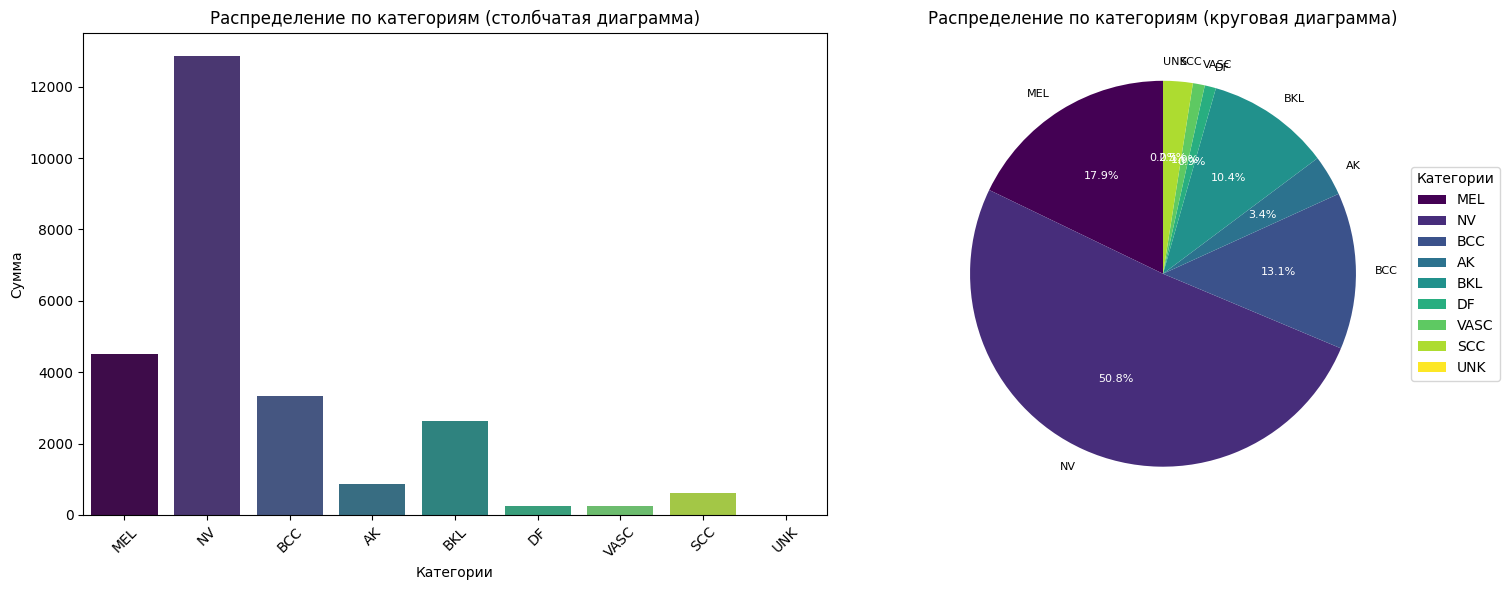

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

stat_ISIC = ISIC_DF[ISIC_DF.columns[1:]].sum()

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Столбчатая диаграмма с индивидуальными цветами
# Создаем палитру с разными цветами для каждого столбца
n_colors = len(stat_ISIC)
colors = plt.cm.viridis(np.linspace(0, 1, n_colors))  # можно использовать другие палитры: tab10, viridis, plasma

sns.barplot(x=stat_ISIC.index, y=stat_ISIC.values, ax=ax1, palette=colors)
ax1.set_title('Распределение по категориям (столбчатая диаграмма)')
ax1.set_xlabel('Категории')
ax1.set_ylabel('Сумма')
ax1.tick_params(axis='x', rotation=45)

# 2. Круговая диаграмма
# Для круговой диаграммы используем те же цвета
wedges, texts, autotexts = ax2.pie(stat_ISIC.values, 
                                     labels=stat_ISIC.index,
                                     colors=colors,
                                     autopct='%2.1f%%',
                                     startangle=90)

# Настройка внешнего вида текста на круговой диаграмме
for text in texts:
    text.set_fontsize(8)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color('white')

ax2.set_title('Распределение по категориям (круговая диаграмма)')

# Добавляем легенду для круговой диаграммы (опционально)
ax2.legend(wedges, stat_ISIC.index, 
           title="Категории",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

In [23]:
percent_isic = stat_ISIC/sum(stat_ISIC)
percent_isic

MEL     0.178516
NV      0.508270
BCC     0.131183
AK      0.034227
BKL     0.103588
DF      0.009435
VASC    0.009988
SCC     0.024792
UNK     0.000000
dtype: float64

In [25]:
percent_isic[percent_isic < 0.01]

DF      0.009435
VASC    0.009988
UNK     0.000000
dtype: float64

- Melanoma

- Melanocytic nevus

- Basal cell carcinoma

- Actinic keratosis

- Benign keratosis (solar lentigo / seborrheic keratosis / lichen planus-like keratosis)

- Dermatofibroma

- Vascular lesion

- Squamous cell carcinoma

- None of the above

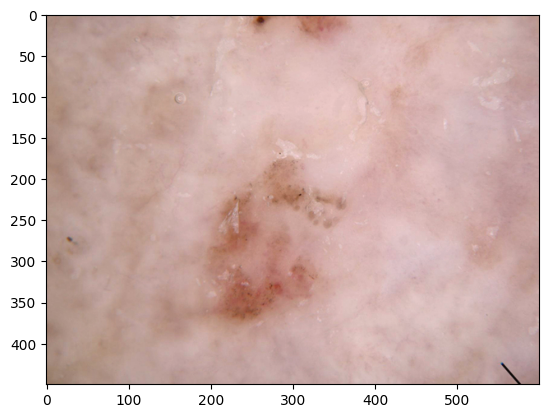

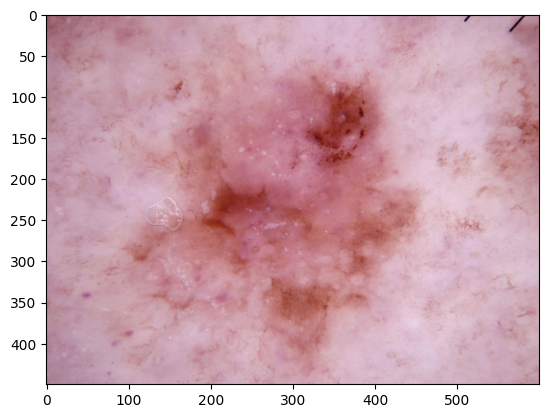

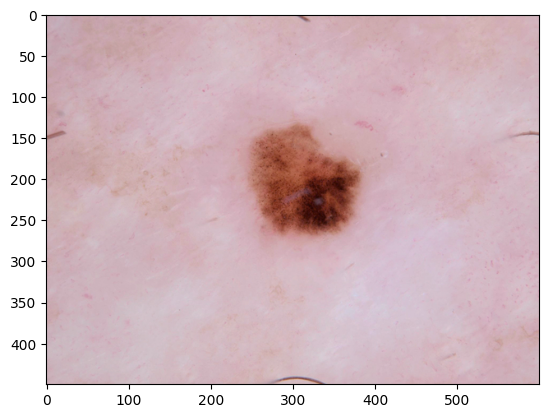

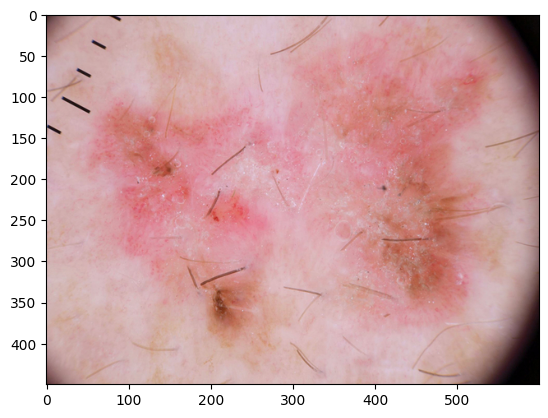

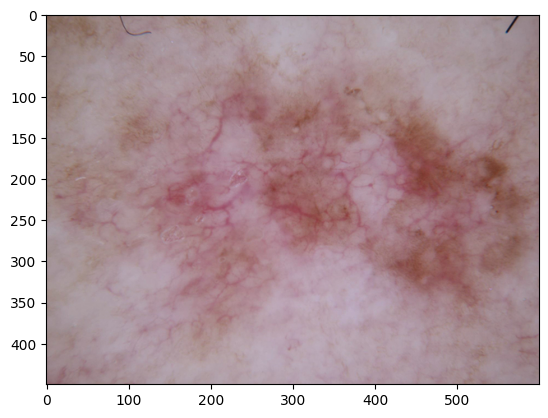

In [34]:
IMAGE_SCC = list(ISIC_DF[ISIC_DF["SCC"]==1].image)
import cv2
from PIL import Image
for pic_path in IMAGE_SCC[:5]:
    path = os.path.join("/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input",pic_path + ".jpg")
    img = Image.open(path)
    # img_rgb = img[:, :, ::-1]  
    plt.imshow(img)
    plt.show()
        